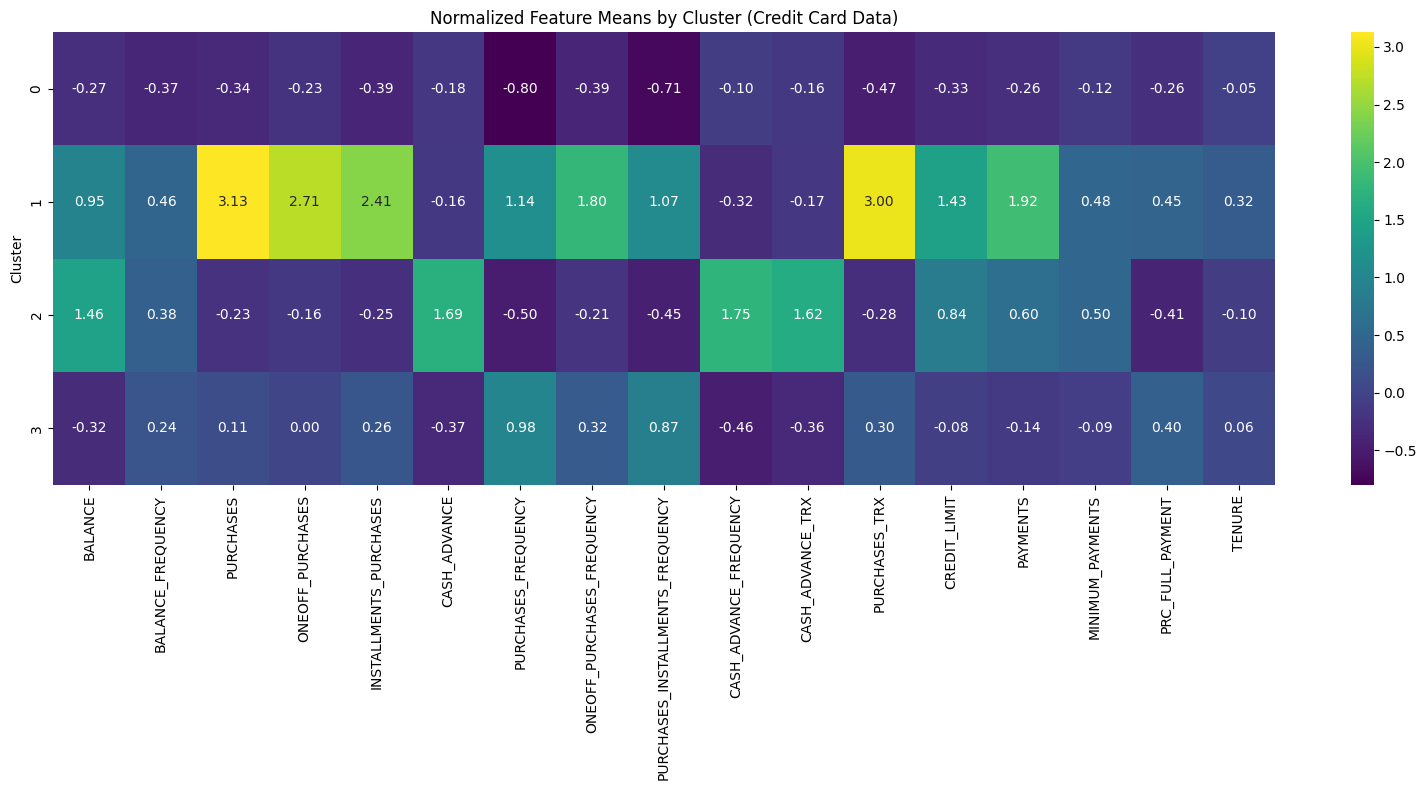

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read the Credit Card dataset
url = "https://raw.githubusercontent.com/majidramzi/clustering/refs/heads/main/credit-card/credit-card.csv"
df = pd.read_csv(url)

# 1. Preprocessing: Drop non-numeric ID column
if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)

# 2. Preprocessing: Handle missing values by filling with median
df = df.fillna(df.median())

# 3. Feature Scaling (Essential for varied financial metrics)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 4. Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Extract and plot normalized cluster centers
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])

plt.figure(figsize=(16, 8))
sns.heatmap(cluster_centers, annot=True, cmap='viridis', fmt=".2f")
plt.title('Normalized Feature Means by Cluster (Credit Card Data)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

The Credit Card dataset represents an advanced clustering scenario due to its high dimensionality and missing values. After dropping the non-predictive customer ID and imputing missing values with the median, feature scaling was applied to balance variables with vastly different ranges, such as credit limits and purchase frequencies. The K-Means algorithm grouped the users into four distinct financial behaviors.

Cluster 0 represents conservative users who maintain low balances and make infrequent purchases.

Cluster 1 identifies active, high-frequency shoppers who utilize their cards regularly for standard purchases but keep a manageable balance.

Cluster 2 highlights the most lucrative segment: big spenders with the highest credit limits and purchase volumes, particularly in expensive or one-off transactions.

Cluster 3 captures cash-advance dependents; these users have high balances and frequently withdraw cash rather than making direct purchases, indicating potential credit risk.